*2026 Spring DSAA 2011 Maching Learning*
## Lab Note 10 (Solution)
*Shuyu Shen,Yang Luo, Zixin Zhong* \
*Hong Kong University of Science and Technology (Guangzhou)*

### Question 1: Nonlinear Classification using SVM

In this section, we will explore **nonlinear classification** using Support Vector Machines (SVMs). In many real-world scenarios, data is **not linearly separable**—meaning that a straight line (or hyperplane) cannot effectively separate the classes.  

To handle such cases, we can use **SVMs with nonlinear kernels**. Specifically, we will apply an **SVM with a Gaussian kernel** to two different datasets:  

- `LA10-nonlinear-data1.csv`  
- `LA10-nonlinear-data2.csv`  

These datasets contain data points that cannot be separated by a simple linear boundary. Instead, we will leverage the power of **kernel functions** to transform the input space into a higher-dimensional feature space, where the data becomes linearly separable.  

**Provided Dataset Visualizations:**  

1. LA10-nonlinear-data1.csv
<p align="center">
  <img src="LA10-nonlinear-data1.png" alt="Data1" width="10%">
</p>

2. LA10-nonlinear-data2.csv
<p align="center">
  <img src="LA10-nonlinear-data2.png" alt="Data1" width="10%">
</p>

### **Tasks**  
Now, you are required to complete the following tasks:  

1. **Implement the Gaussian kernel function**.  
2. **Train an SVM model using the Gaussian kernel** on the two datasets (`LA10-nonlinear-data1.csv` and `LA10-nonlinear-data2.csv`).  
3. **Visualize the decision boundary** to illustrate how the kernel SVM separates the two classes.  
4. **Experiment with different kernel functions** (e.g., polynomial, sigmoid) and **compare their performance** on the datasets.  

**Tips:**

1. **SVM for non-linear classification:**

* Instead of defining a nonlinear model in the original (input) space, the problem is mapped to a new (feature) space by performing a **nonlinear transformation** using a suitably chosen **basis functions**. 
* The basis functions are often defined implicitly via definning kernel functions directly. 
* In this new feature space, the problem is expected to be linearly separable. The SVM model can then be applied to find the optimal hyperplane in this new space. 

2. **Guassian kernel:**

* You can think of the Gaussian kernel as a similarity function that measures the “distance” between a pair of examples (x(i), x(j)). 
* The Gaussian kernel is also parameterized by a bandwidth parameter $\sigma$, which determines how fast the similarity metric decreases (to 0) as the examples are further apart.
And the definition of the Gaussian kernel is:
$$
K_{\text{gaussian}}(x^{(i)}, x^{(j)}) = \exp\left(-\frac{\|x^{(i)} - x^{(j)}\|^2}{2\sigma^2}\right) = \exp \left(-\frac{\sum_{k=1}^{n}(x_k^{(i)} - x_k^{(j)})^2}{2\sigma^2}\right)
$$


**Your solution here:**

In [18]:
# 1. Implement Gaussian kernel function
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import svm

def gaussian_kernel(x1, x2, sigma=.1):
    """
    The guassian kernel function
    :param x1: input vector
    :param x2: input vector
    :param sigma: bandwidth parameter
    :return: similarity between x1 and x2
    """
    x1 = x1.flatten()
    x2 = x2.flatten()

    sim = 0

    # ===================== Your Code Here =====================
    # ==========================================================
    
    sim = np.exp(-np.sum((x1 - x2) ** 2) / (2 * (sigma ** 2)))
    
    return sim

In [19]:
# test your implementation, if the output is 0.324652, it is correct
x1 = np.array([1, 2, 1])
x2 = np.array([0, 4, -1])
sigma = 2
sim = gaussian_kernel(x1, x2, sigma)
print(sim) 

0.32465246735834974


         x1        x2  label
0  0.107143  0.603070      1
1  0.093318  0.649854      1
2  0.097926  0.705409      1
3  0.155530  0.784357      1
4  0.210829  0.866228      1


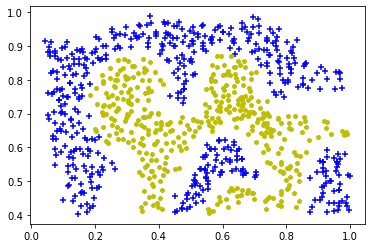

In [20]:
# Load the dataset and visualize the data
def plot_data(X, y):
    plt.figure()
    pos = np.where(y == 1.)[0]
    neg = np.where(y == 0.)[0]

    plt.scatter(X[pos, 0], X[pos, 1], marker="+", c='b')
    plt.scatter(X[neg, 0], X[neg, 1], marker="o", c='y', s=15)

data = pd.read_csv('LA10-nonlinear-data1.csv', header=None, skiprows=1)
data.columns = ['x1', 'x2', 'label']
print(data.head())

X = data.iloc[:, [0, 1]]
y = data.iloc[:, 2]
plot_data(X.values, y.values)

         x1        x2  label
0  0.107143  0.603070      1
1  0.093318  0.649854      1
2  0.097926  0.705409      1
3  0.155530  0.784357      1
4  0.210829  0.866228      1


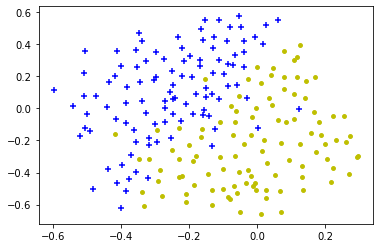

In [21]:
data2 = pd.read_csv('LA10-nonlinear-data2.csv', header=None, skiprows=1)
data2.columns = ['x1', 'x2', 'label']
print(data.head())

X2 = data2.iloc[:, [0, 1]]
y2 = data2.iloc[:, 2]
plot_data(X2.values, y2.values)

In [22]:
# 2.1 Train the SVM model using the Gaussian kernel on dataset 1
def kernel(x1, x2):
    n = x1.shape[0]
    m = x2.shape[0]
    K = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            K[i, j] = gaussian_kernel(x1[i], x2[j])
    return K

# ===================== Your Code Here =====================
# ==========================================================

clf = svm.SVC(kernel=kernel, C=1) 
# C = Regularization parameter
clf.fit(X.values, y.values)

SVC(C=1, kernel=<function kernel at 0x0000022C02A97430>)

C:\Users\dobby\AppData\Local\Temp/ipykernel_24052/2880001655.py:39: UserWarning: No contour levels were found within the data range.
  plt.contour(xx, yy, Z, levels=[0], colors='r')


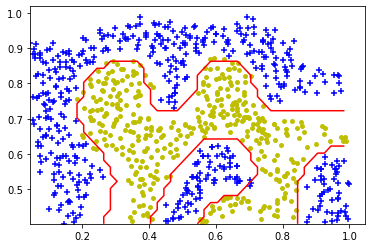

In [ ]:
def visualize_boundary(clf, x1_min, x1_max, x2_min, x2_max):
    """
    Visualize the decision boundary of a trained SVM model.

    The function generates a dense 2D grid over the feature space,
    predicts the class for every point on the grid using the trained SVM,
    and then draws the contour line where the predicted class changes,
    which corresponds to the decision boundary.
    """

    # Step size of the grid; smaller values produce smoother boundaries
    h = .02

    # Generate a mesh grid covering the specified region
    # xx contains all x1 coordinates, yy contains all x2 coordinates
    xx, yy = np.meshgrid(
        np.arange(x1_min, x1_max, h),
        np.arange(x2_min, x2_max, h)
    )

    # -------------------------------------------------------------
    # Step 1: Predict class labels for each point in the grid
    # Flatten the grid points and combine them into coordinate pairs
    # np.c_[...] converts two 1D arrays into an (N, 2) array for prediction
    

    # -------------------------------------------------------------
    # Step 3: Draw the decision boundary
    # contour(levels=[0]) draws the boundary where the predicted class changes
    # This line represents the SVM decision boundary
    # -------------------------------------------------------------
    plt.contour(xx, yy, Z, levels=[0], colors='r')
# -------------------------------------------------------------
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # -------------------------------------------------------------
    # Step 2: Reshape the prediction results back to the grid shape
    # so the contour plot aligns correctly with the mesh
    # -------------------------------------------------------------
    Z = Z.reshape(xx.shape)

plot_data(X.values, y.values)
visualize_boundary(clf, X['x1'].min(), X['x1'].max(), X['x2'].min(), X['x2'].max())

C:\Users\dobby\AppData\Local\Temp/ipykernel_24052/2880001655.py:39: UserWarning: No contour levels were found within the data range.
  plt.contour(xx, yy, Z, levels=[0], colors='r')


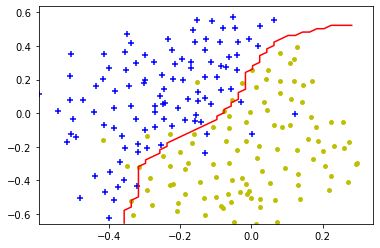

In [24]:
# 2.2. Train the SVM model using the Gaussian kernel on dataset 2
# ===================== Your Code Here =====================
# ==========================================================
    
clf2 = svm.SVC(kernel=kernel, C=1)
clf2.fit(X2.values, y2.values)
plot_data(X2.values, y2.values)
visualize_boundary(clf2, X2['x1'].min(), X2['x1'].max(), X2['x2'].min(), X2['x2'].max())

C:\Users\dobby\AppData\Local\Temp/ipykernel_24052/2880001655.py:39: UserWarning: No contour levels were found within the data range.
  plt.contour(xx, yy, Z, levels=[0], colors='r')
C:\Users\dobby\AppData\Local\Temp/ipykernel_24052/2880001655.py:39: UserWarning: No contour levels were found within the data range.
  plt.contour(xx, yy, Z, levels=[0], colors='r')


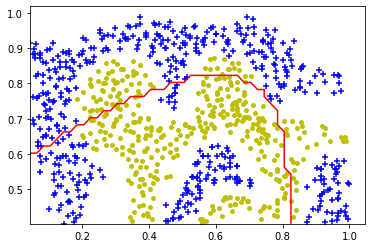

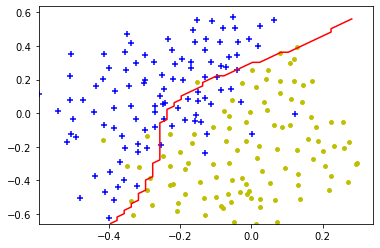

In [25]:
# 4. Try to chose different kernel functions and compare the results
# ===================== Your Code Here =====================
# ==========================================================

# Polynomial kernel
clf_poly = svm.SVC(kernel='poly', degree=3)
clf_poly.fit(X.values, y.values)
plot_data(X.values, y.values)
visualize_boundary(clf_poly, X['x1'].min(), X['x1'].max(), X['x2'].min(), X['x2'].max())

clf_poly2 = svm.SVC(kernel='poly', degree=3)
clf_poly2.fit(X2.values, y2.values)
plot_data(X2.values, y2.values)
visualize_boundary(clf_poly2, X2['x1'].min(), X2['x1'].max(), X2['x2'].min(), X2['x2'].max())

**Question 2**   
Please run the following code to generate a dataset and complete the following tasks  
**Task**
1. Plot a scatter plot of the dataset and describe its characteristics.
2. Use the K-Means algorithm from scikit-learn to cluster the dataset, then plot a scatter plot to analyze the clustering performance.
3. Implement a Kernel K-Means algorithm to cluster the dataset and compare the results.

In [26]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=1000, noise=0.1, factor=0.3, random_state=42)
# Generate a 2D concentric circles dataset:
# - n_samples=1000: total number of points
# - noise=0.1: Gaussian noise added to the data
# - factor=0.3: inner circle radius is 30% of the outer circle
# - random_state=42: ensures reproducible results


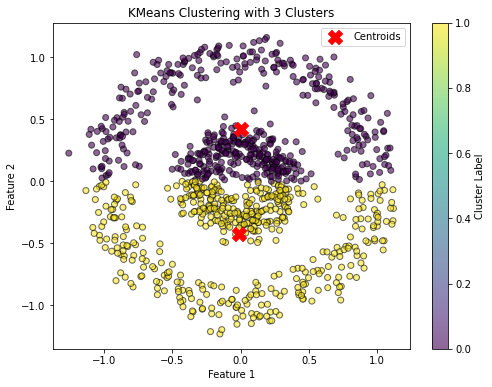

In [27]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2)  
kmeans.fit(X)  
cluster_labels = kmeans.labels_          
centroids = kmeans.cluster_centers_
# 绘制聚类结果
plt.figure(figsize=(8, 6))

# 画出每个簇的数据点
scatter = plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, alpha=0.6, edgecolor='k')

# 画出簇中心点
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

# 添加标签和标题
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clustering with 3 Clusters')
plt.legend()
plt.colorbar(scatter, label='Cluster Label')
plt.show()




\begin{aligned}
\text{term1} &= K(x, x) 
\end{aligned}

\begin{aligned}
\text{term2} &= \frac{2}{|C_k|}\sum_{x_j \in C_k} K(x, x_j)
\end{aligned}

\begin{aligned}
\text{term3} &= \frac{1}{|C_k|^2}\sum_{x_p, x_q \in C_k} K(x_p, x_q)
\end{aligned}




\begin{aligned}
D(x, C_k) = \text{term1} - \text{term2} + \text{term3}
\end{aligned}



term1 measures how similar each sample is to itself; it is a constant reference value.

term2 measures the average similarity between the sample and all points in the cluster.

term3 measures the average similarity among all points inside the cluster, representing how compact the cluster is.

In [28]:
import numpy as np

class RBFKernelKMeans:
    def __init__(self, n_clusters=3, max_iter=300, random_state=None, gamma=None):
        """
        Parameters for RBF Kernel K-Means:
        :param gamma: RBF kernel parameter γ. Default is 1 / (number of features).
        :Other parameters follow the standard K-Means setting.
        """
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.gamma = gamma
        self.labels = None
        self.K = None       # Cached kernel matrix
        self.X = None       # Store original input data

    def _rbf_kernel(self, X):
        """Efficient computation of the RBF (Gaussian) kernel matrix."""
        if self.gamma is None:
            gamma = 1.0 / X.shape[1]  # Default γ = 1 / feature dimension
        else:
            gamma = self.gamma
        
        # Compute squared Euclidean distance matrix using vectorized operations
        sq_dists = (
            np.sum(X**2, axis=1, keepdims=True) +
            np.sum(X**2, axis=1) -
            2 * np.dot(X, X.T)
        )
        
        return np.exp(-gamma * sq_dists)

    def _initialize_clusters(self, n_samples):
        """
        Improved initialization: ensure that every cluster has at least one sample.
        """
        np.random.seed(self.random_state)
        init_labels = np.random.randint(0, self.n_clusters, n_samples)
        
        # Handle empty clusters
        for _ in range(100):  # Try up to 100 times
            unique_clusters = np.unique(init_labels)
            if len(unique_clusters) == self.n_clusters:
                break
            # Assign missing cluster IDs to random samples
            missing = set(range(self.n_clusters)) - set(unique_clusters)
            for m in missing:
                init_labels[np.random.choice(n_samples)] = m
        return init_labels

    def fit(self, X):
        self.X = X
        n_samples = X.shape[0]
        
        # Step 1: Precompute the full kernel matrix
        self.K = self._rbf_kernel(X)
        
        # Step 2: Initialize cluster assignments (avoid empty clusters)
        self.labels = self._initialize_clusters(n_samples)
        
        # Step 3: Iterative optimization (Kernel K-Means)
        for _ in range(self.max_iter):
            # Distance matrix: each row is a sample, each column a cluster
            distance_matrix = np.zeros((n_samples, self.n_clusters))
            
            for cluster_id in range(self.n_clusters):
                # Get indices of samples assigned to this cluster
                mask = (self.labels == cluster_id)
                n_cluster_samples = np.sum(mask)
                
                if n_cluster_samples == 0:
                    # Assign infinite distance if cluster is empty
                    distance_matrix[:, cluster_id] = np.inf
                    continue
                
                # Kernel-space distance decomposition:
                term1 = np.diag(self.K)                     # K(x, x)
                term2 = 2 * self.K[:, mask].mean(axis=1)    # 2 * E[K(x, c)]
                term3 = self.K[mask][:, mask].mean()        # E[K(c, c')]
                
                distance_matrix[:, cluster_id] = term1 - term2 + term3
            
            # Assign new labels based on minimum kernel distance
            new_labels = np.argmin(distance_matrix, axis=1)
            
            # Convergence check
            if np.array_equal(self.labels, new_labels):
                break
                
            self.labels = new_labels


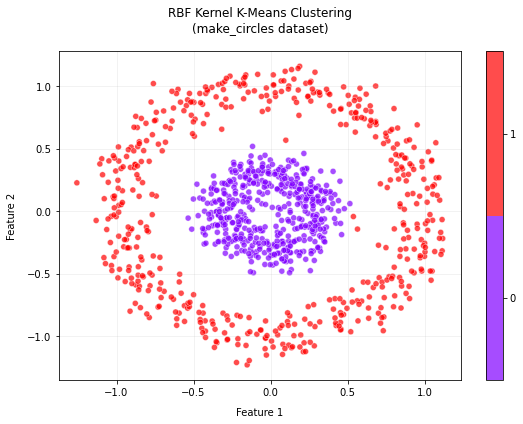

In [29]:
import matplotlib.pyplot as plt

# 创建模型并拟合数据
model = RBFKernelKMeans(n_clusters=2, gamma=10, random_state=42)  # 关键参数设置
model.fit(X)
# 可视化聚类结果
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=model.labels, cmap='rainbow', alpha=0.7, edgecolors='w', linewidth=0.5)
plt.title("RBF Kernel K-Means Clustering\n(make_circles dataset)", pad=20)
plt.xlabel("Feature 1", labelpad=10)
plt.ylabel("Feature 2", labelpad=10)
plt.grid(alpha=0.2)
plt.tight_layout()

# 显示色标
plt.colorbar(boundaries=np.arange(3)-0.5).set_ticks([0, 1])
plt.show()

**Question 3**   Please load the **L10_data3.csv** file to obtain the dataset, then complete the following tasks. 
Run the following code and analyze the two density-based clustering algorithms.


Density-Based Spatial Clustering of Applications with Noise (DBSCAN)

eps: 0.1,	min_samples: 10,	n_cluster: 3,	n_noise: 405


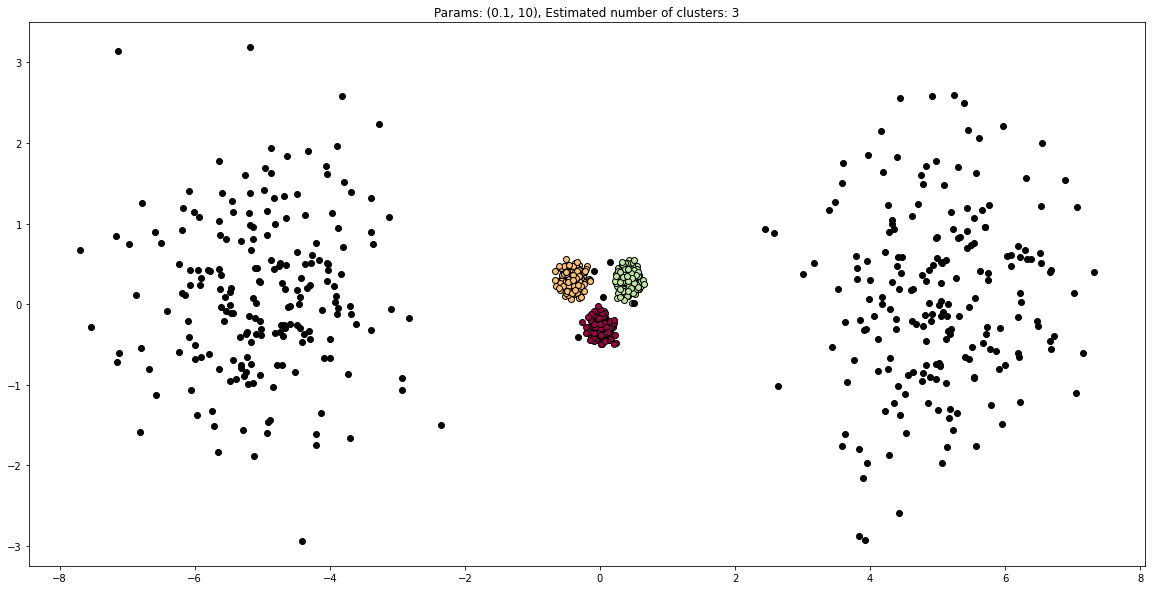

eps: 0.25,	min_samples: 10,	n_cluster: 8,	n_noise: 326


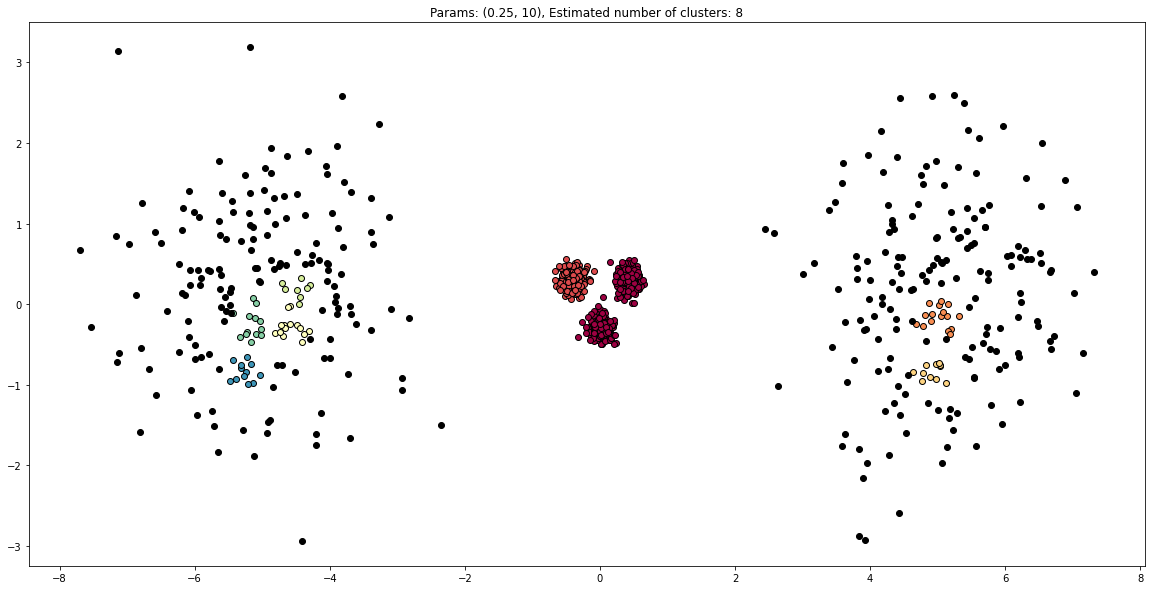

eps: 0.5,	min_samples: 10,	n_cluster: 3,	n_noise: 88


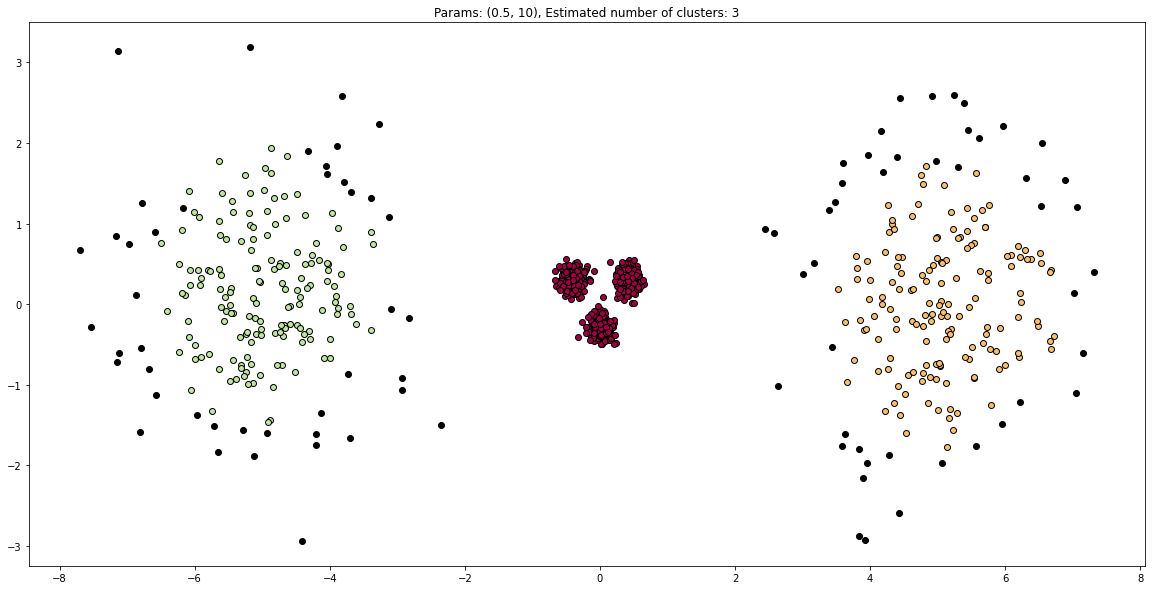

eps: 1,	min_samples: 10,	n_cluster: 3,	n_noise: 4


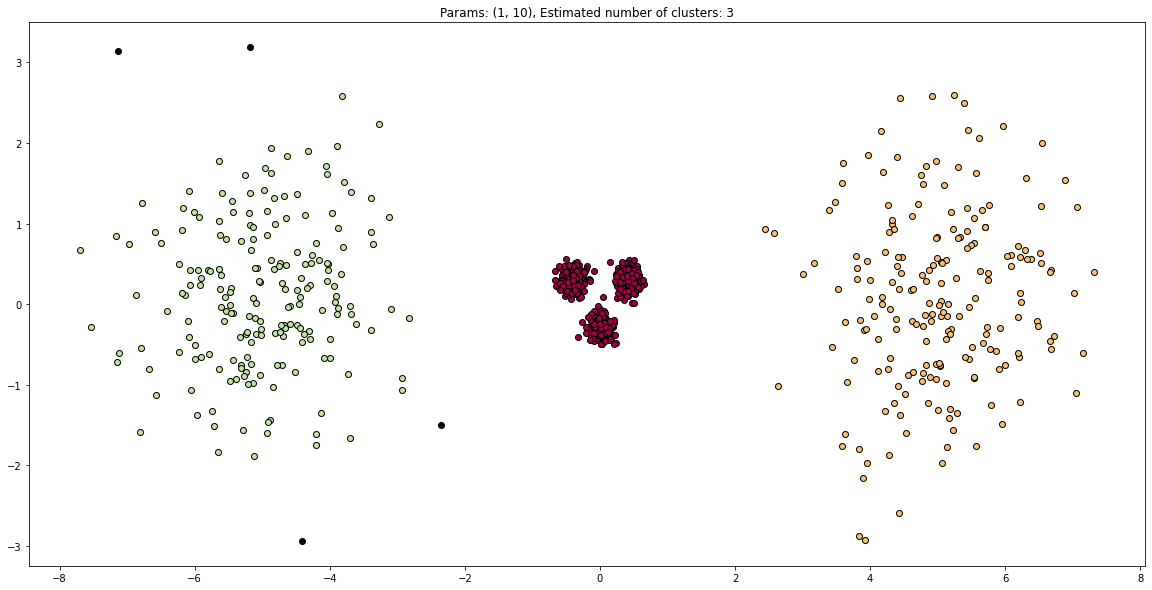

eps: 1.5,	min_samples: 10,	n_cluster: 3,	n_noise: 1


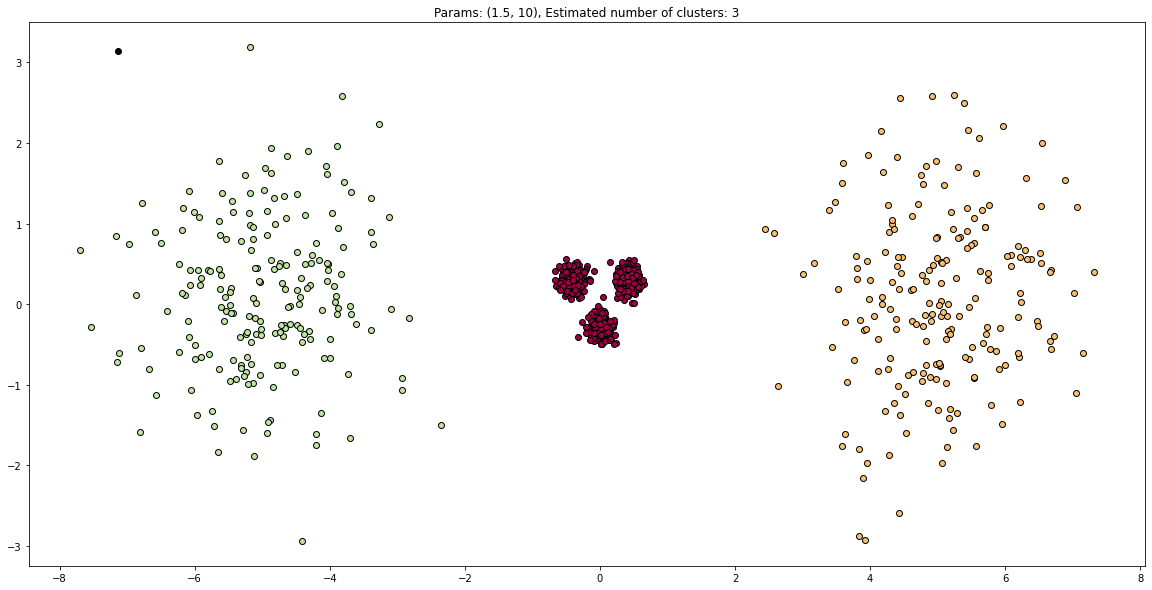

eps: 2,	min_samples: 10,	n_cluster: 2,	n_noise: 0


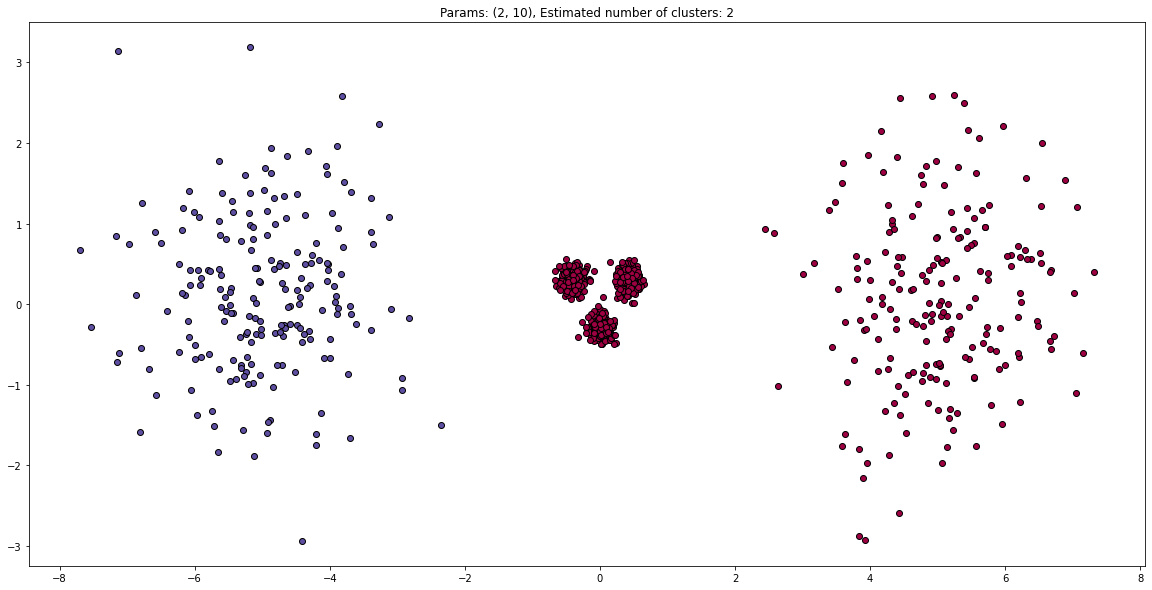

In [30]:
# Authors: Weikai
# SPDX-License-Identifier: BSD-3-Clause
# Adopted from https://scikit-learn.org/stable/auto_examples/cluster/plot_dbscan.html
import numpy as np
from sklearn import metrics
from sklearn.cluster import DBSCAN, OPTICS, cluster_optics_dbscan
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np


np.random.seed(42)
n_points_per_cluster = 200

C1 = [0, -0.3] + 0.1 * np.random.randn(n_points_per_cluster, 2)
C2 = [-0.4, 0.3] + 0.1 * np.random.randn(n_points_per_cluster, 2)
C3 = [0.4, 0.3] + 0.1 * np.random.randn(n_points_per_cluster, 2)
C4 = [5, 0] + 1 * np.random.randn(n_points_per_cluster, 2)
C5 = [-5, 0] + 1 * np.random.randn(n_points_per_cluster, 2)
X = np.vstack((C1, C2, C3, C4, C5))

def DBSCAN_exp(X, eps, min_samples, draw=False):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    labels = db.labels_
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)
    print(f"eps: {eps},\tmin_samples: {min_samples},\tn_cluster: {n_clusters_},\tn_noise: {n_noise_}")
    if draw:
        unique_labels = set(labels)
        core_samples_mask = np.zeros_like(labels, dtype=bool)
        core_samples_mask[db.core_sample_indices_] = True
        colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
        plt.figure(figsize=(20, 10))
        for k, col in zip(unique_labels, colors):
            if k == -1:
                # Black used for noise.
                col = [0, 0, 0, 1]
        
            class_member_mask = labels == k
        
            xy = X[class_member_mask & core_samples_mask]
            
            plt.plot(
                xy[:, 0],
                xy[:, 1],
                "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=6,
            )
        
            xy = X[class_member_mask & ~core_samples_mask]
            plt.plot(
                xy[:, 0],
                xy[:, 1],
                "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=6,
            )
        plt.title(f"Params: {eps, min_samples}, Estimated number of clusters: {n_clusters_}")
        plt.show()

for eps in [0.1,0.25,0.5,1,1.5,2]:
    for min_samples in [10]: #min_samples specifies the minimum number of points that must exist within a point’s ε-neighborhood for that point to be considered a core point.
        DBSCAN_exp(X,eps,min_samples, True)


When ε is small, DBSCAN identifies only very tight groups as clusters, causing many points, especially those in sparse or distant regions, to be labeled as noise. As ε increases, the algorithm starts to merge nearby points and small groups, reducing the number of noise points and forming larger clusters. Eventually, when ε becomes too large, distinct clusters begin to merge into fewer, coarse clusters.

OPTICS is a generalization of DBSCAN, designed to overcome DBSCAN’s high sensitivity to the choice of ε (eps).
The core idea of OPTICS is to avoid fixing a single ε and instead explore all possible ε values to reveal the full density structure of the data.

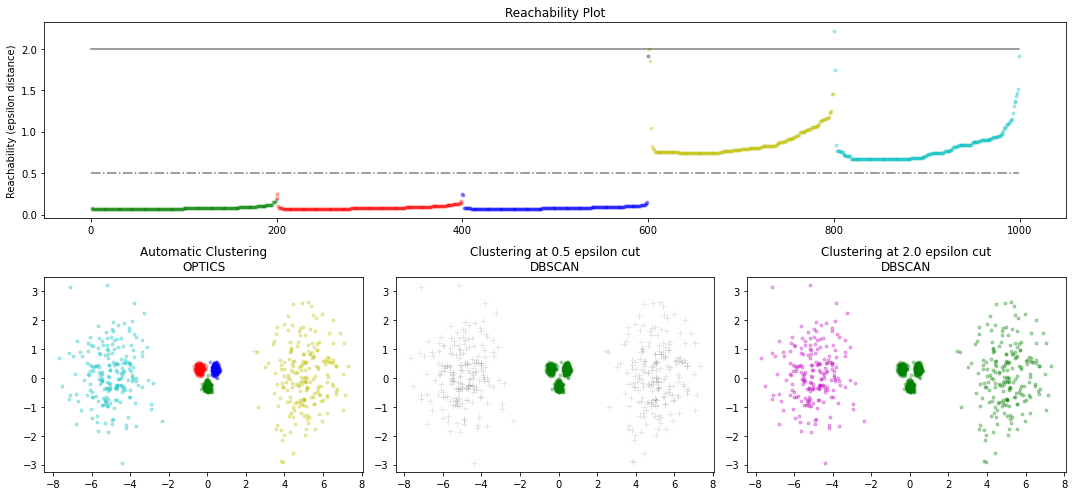

In [ ]:

    clust = OPTICS(min_samples=50, xi=0.05, min_cluster_size=0.05) #xi is used to determine where the reachability curve shows a “sufficiently steep drop or rise.”

    # Run the fit
    clust.fit(X)

    labels_050 = cluster_optics_dbscan(
        reachability=clust.reachability_,
        core_distances=clust.core_distances_,
        ordering=clust.ordering_,
        eps=0.5,
    )
    labels_200 = cluster_optics_dbscan(
        reachability=clust.reachability_,
        core_distances=clust.core_distances_,
        ordering=clust.ordering_,
        eps=2,
    )

    space = np.arange(len(X))
    reachability = clust.reachability_[clust.ordering_]
    labels = clust.labels_[clust.ordering_]

    plt.figure(figsize=(15, 7))
    G = gridspec.GridSpec(2, 3)
    ax1 = plt.subplot(G[0, :])
    ax2 = plt.subplot(G[1, 0])
    ax3 = plt.subplot(G[1, 1])
    ax4 = plt.subplot(G[1, 2])

    # Reachability plot
    colors = ["g.", "r.", "b.", "y.", "c."]
    for klass, color in enumerate(colors):
        Xk = space[labels == klass]
        Rk = reachability[labels == klass]
        ax1.plot(Xk, Rk, color, alpha=0.3)
    ax1.plot(space[labels == -1], reachability[labels == -1], "k.", alpha=0.3)
    ax1.plot(space, np.full_like(space, 2.0, dtype=float), "k-", alpha=0.5)
    ax1.plot(space, np.full_like(space, 0.5, dtype=float), "k-.", alpha=0.5)
    ax1.set_ylabel("Reachability (epsilon distance)")
    ax1.set_title("Reachability Plot")

    # OPTICS
    colors = ["g.", "r.", "b.", "y.", "c."]
    for klass, color in enumerate(colors):
        Xk = X[clust.labels_ == klass]
        ax2.plot(Xk[:, 0], Xk[:, 1], color, alpha=0.3)
    ax2.plot(X[clust.labels_ == -1, 0], X[clust.labels_ == -1, 1], "k+", alpha=0.1)
    ax2.set_title("Automatic Clustering\nOPTICS")

    # DBSCAN at 0.5
    colors = ["g.", "r.", "b.", "c."]
    for klass, color in enumerate(colors):
        Xk = X[labels_050 == klass]
        ax3.plot(Xk[:, 0], Xk[:, 1], color, alpha=0.3)
    ax3.plot(X[labels_050 == -1, 0], X[labels_050 == -1, 1], "k+", alpha=0.1)
    ax3.set_title("Clustering at 0.5 epsilon cut\nDBSCAN")

    # DBSCAN at 2.
    colors = ["g.", "m.", "y.", "c."]
    for klass, color in enumerate(colors):
        Xk = X[labels_200 == klass]
        ax4.plot(Xk[:, 0], Xk[:, 1], color, alpha=0.3)
    ax4.plot(X[labels_200 == -1, 0], X[labels_200 == -1, 1], "k+", alpha=0.1)
    ax4.set_title("Clustering at 2.0 epsilon cut\nDBSCAN")

    plt.tight_layout()
    plt.show()

Figure 1: From the OPTICS perspective, different clusters can be obtained by cutting the reachability plot at different levels. In the reachability plot, each cluster appears as a continuous valley of low reachability values, while the boundaries between clusters are marked by sharp increases.

Figure 2: The clustering result produced directly by OPTICS itself (independent of ε).


Figure 3: A smaller ε leads to finer clusters and more noise points. Only the regions where reachability < 0.5 can form clusters. As a result, only the three small, high-density clusters in the center are detected, while the two larger clusters on both sides are treated as noise due to their lower density.

Figure 4: A larger ε tends to merge clusters, producing fewer noise points but coarser cluster structures.

OPTICS performs automatic clustering by using ξ to detect steep changes in the reachability curve, allowing it to identify natural cluster boundaries without relying on a single ε value. In contrast, DBSCAN can only detect density-based clusters defined by the specific ε threshold it is given, which is why ε = 0.5 and ε = 2.0 cannot reproduce the clustering result obtained by OPTICS.


**Question 4** Please load the **L10_data3.csv** file to obtain the dataset, then complete the following tasks.  
**Task**  
1. Please use scikit-learn to implement K-Means, DBSCAN, and hierarchical clustering for clustering analysis
2. Visualize and compare the performance of all three clustering methods using plots.

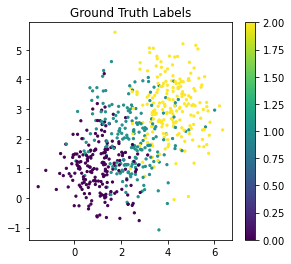

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 读取数据（假设数据格式为x,y,label的CSV）
data = pd.read_csv('L10_data3.csv', sep='\t')
data = data['x,y,label'].str.split(',', expand=True)
data.columns = ['x', 'y', 'label']
data['x'] = data['x'].astype(float)
data['y'] = data['y'].astype(float)
true_labels = data['label'].astype(int).values
X = data[['x', 'y']].values

# 绘制原始数据（按真实标签）
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=true_labels, s=5, cmap='viridis')
plt.title("Ground Truth Labels")
plt.colorbar()


ARI is a score that evaluates clustering accuracy while correcting for chance.

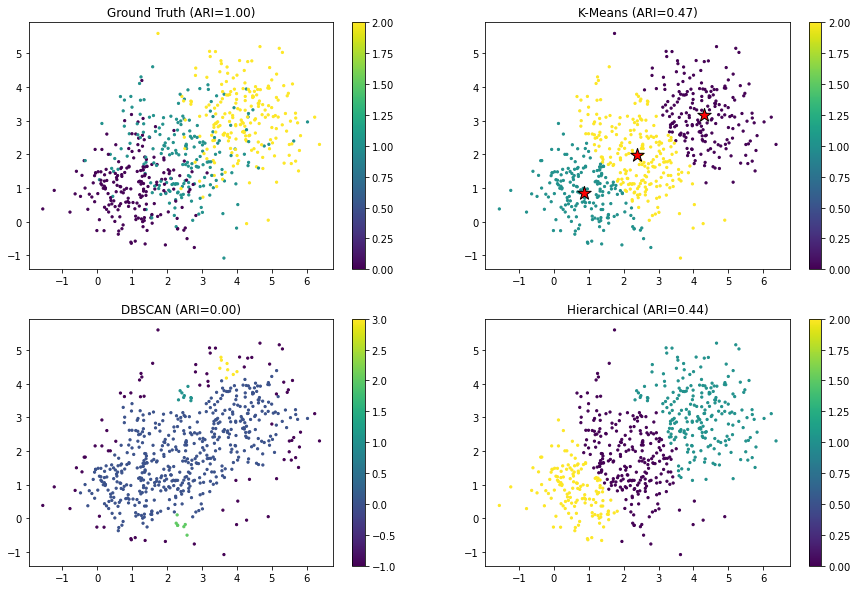

In [35]:
from typing import Any


from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

# Three clustering methods
kmeans = KMeans(n_clusters=3, random_state=42).fit(X)
dbscan = DBSCAN(eps=0.3, min_samples=5).fit(X)
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward').fit(X)

# Visualiation
plt.figure(figsize=(15, 10))
titles = ["Ground Truth", "K-Means", "DBSCAN", "Hierarchical"]
labels_list = [true_labels, kmeans.labels_, dbscan.labels_, hierarchical.labels_]

for i, (title, labels) in enumerate(zip(titles, labels_list)):
    plt.subplot(2, 2, i+1)
    sc = plt.scatter(X[:, 0], X[:, 1], c=labels, s=5, cmap='viridis')

    # KMeans 
    if title == "K-Means":
        plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
                    s=200, marker='*', c='red', edgecolor='black')

    plt.title(f"{title} (ARI={adjusted_rand_score(true_labels, labels):.2f})")
    plt.colorbar(sc)

plt.show()
